# K-Means sur MNIST

- Algorithme de Lloyd ([src/kmeans.py](../src/kmeans.py)).
- Images 28x28 en niveaux de gris, dix chiffres manuscrits (0-9) ;
- Approche générale :
  - `encode(X)` : indice du centroïde le plus proche, le code latent discret.
  - `decode(latent)` : chaque code redevient son centroïde, la reconstruction.
  - `get_codebook()` : les K centroïdes, le dictionnaire partagé.
- Fil conducteur expérimental : faire varier K et le nombre d'initialisations, mesurer l'effet sur chaque angle.

In [15]:
import sys
from pathlib import Path

# src/ importable et racine du projet comme dossier courant
ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
import os
os.chdir(ROOT)

import numpy as np
import matplotlib.pyplot as plt

from src.kmeans import KMeans
from src.metrics import compression_report, Latent
from src.dataset import load_mnist_dataset
from src.helper import extract_full_dataset

rng = np.random.default_rng(0)
%matplotlib inline

## 1. Chargement et préparation des données

- Split `train` de MNIST, `extract_full_dataset` rassemble tous les batches.
- Sous-ensemble de N = 10 000 images : suffisant pour l'étude, assez léger pour ré-exécuter vite.
- Chaque image `(1, 28, 28)` aplatie à la volée en 784 composantes ; `ToTensor` a déjà ramené les pixels dans `[0, 1]`, distance euclidienne homogène.

In [16]:
dataloader = load_mnist_dataset(train=True, batch_size=4096, download=True, shuffle=False)
images, digit_labels = extract_full_dataset(dataloader)

N = 10000
X = images[:N].flatten(start_dim=1).numpy().astype(np.float32)
y = digit_labels[:N].numpy()

class_names = [str(d) for d in range(10)]


def as_image(vec):
    """Reshape a flat pixel vector back to a (H, W) grayscale image for display."""
    return np.clip(vec, 0.0, 1.0).reshape(28, 28)


print("X:", X.shape, X.dtype, "| pixels dans [", X.min(), ",", X.max(), "]")
print("chiffres :", class_names)
print("effectifs par chiffre :", np.bincount(y).tolist())

X: (10000, 784) float32 | pixels dans [ 0.0 , 1.0 ]
chiffres : ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']
effectifs par chiffre : [1001, 1127, 991, 1032, 980, 863, 1014, 1070, 944, 978]


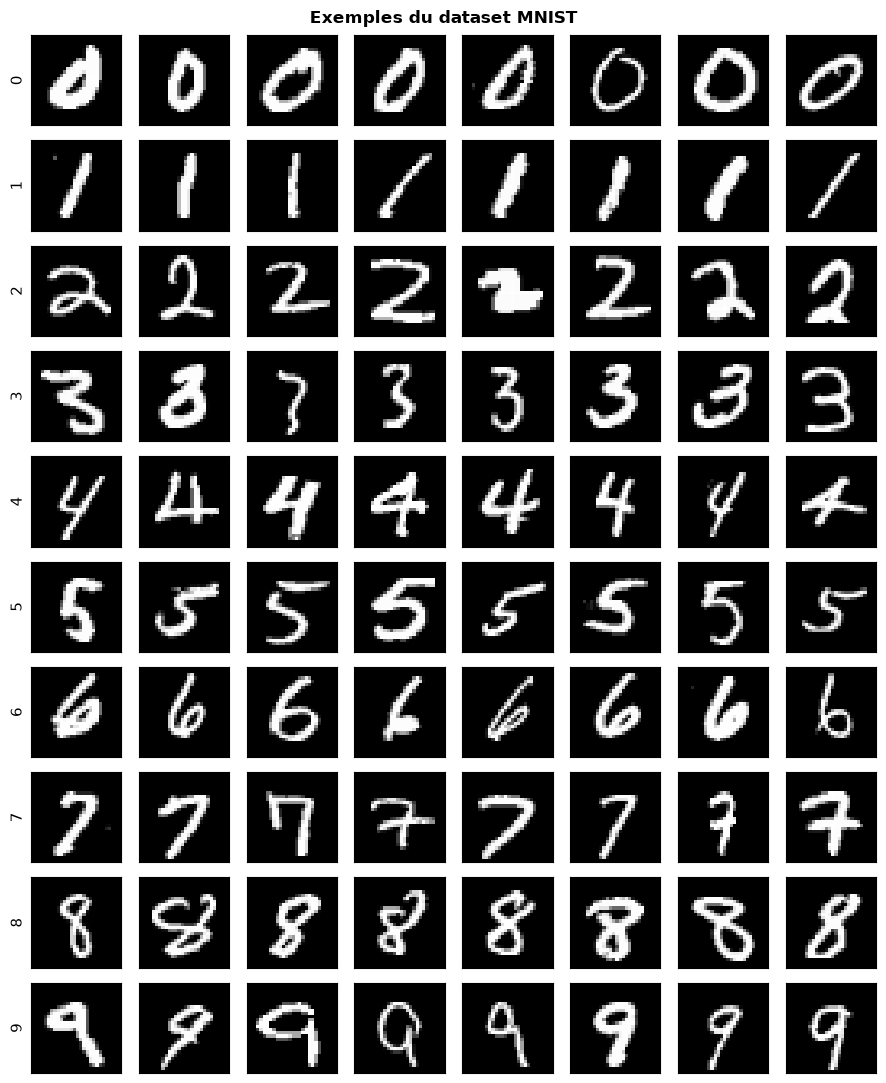

In [17]:
fig, axes = plt.subplots(10, 8, figsize=(9, 11))
for r in range(10):
    picks = rng.choice(np.where(y == r)[0], size=8, replace=False)
    for c in range(8):
        axes[r, c].imshow(as_image(X[picks[c]]), cmap="gray")
        axes[r, c].set_xticks([]); axes[r, c].set_yticks([])
    axes[r, 0].set_ylabel(class_names[r], fontsize=11)
fig.suptitle("Exemples du dataset MNIST", fontweight="bold")
plt.tight_layout()
plt.show()

## 2. Entraînement de K-Means

- Modèle principal à **k = 10**, un chiffre par cluster.
- K-Means minimise l'inertie (somme des distances au carré des points à leur centroïde) mais peut tomber dans un minimum local selon l'initialisation.
- `n_init` lance plusieurs départs indépendants via implem k-means++ et conserve le meilleur ; réglé à 10 sur le modèle principal.
- On entraîne une fois toutes les valeurs de K de `[3, 10, 64, 128, 256, 512]`. Grands K coûteux : `n_init` petit (1-2) et `max_iter` modéré pour tenir le runtime.

In [18]:
K_VALUES = [3, 10, 64, 128, 256, 512]
# n_init / max_iter par K : grand K coûteux -> moins d'initialisations et d'itérations
FIT_CONFIG = {3: (10, 100), 10: (10, 100), 64: (2, 60), 128: (2, 50), 256: (1, 50), 512: (1, 40)}

models = {}
for k in K_VALUES:
    n_init, max_iter = FIT_CONFIG[k]
    models[k] = KMeans(n_clusters=k, n_init=n_init, max_iter=max_iter, random_state=0).fit(X)

kmeans = models[10]  # modèle principal (n_init = 10)

for k in K_VALUES:
    m = models[k]
    print(f"k = {k:3d}  |  n_init = {FIT_CONFIG[k][0]:2d}  |  inertie = {m.inertia_:11,.0f}  |  itérations = {m.n_iter_}")

k =   3  |  n_init = 10  |  inertie =     467,196  |  itérations = 31
k =  10  |  n_init = 10  |  inertie =     388,132  |  itérations = 40
k =  64  |  n_init =  2  |  inertie =     290,083  |  itérations = 60
k = 128  |  n_init =  2  |  inertie =     262,300  |  itérations = 50
k = 256  |  n_init =  1  |  inertie =     234,123  |  itérations = 26
k = 512  |  n_init =  1  |  inertie =     206,342  |  itérations = 20


### Combien d'initialisations ?

- On relance k = 10 depuis dix graines, une seule initialisation chacune, et on observe la dispersion des inerties.
- Courbe "gain apporté par n_init" : inertie du meilleur des n premiers départs, en fonction de n.
- Le meilleur se stabilise vite : k-means++ place déjà des centres bien répartis, chaque départ tombe dans un bassin d'inertie voisin.

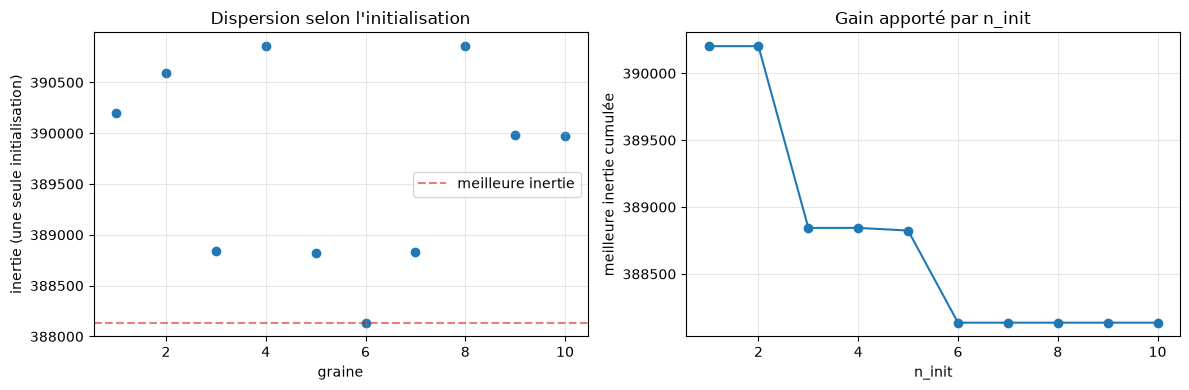

Écart pire / meilleure initialisation : 0.70%
Gain du 1er au 10e départ            : 0.53%


In [19]:
single_inertias = np.array([
    KMeans(n_clusters=10, n_init=1, max_iter=100, random_state=s).fit(X).inertia_
    for s in range(10)
])
best_so_far = np.minimum.accumulate(single_inertias)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.scatter(range(1, 11), single_inertias, color="tab:blue")
ax1.axhline(single_inertias.min(), color="tab:red", linestyle="--", alpha=0.6, label="meilleure inertie")
ax1.set_xlabel("graine")
ax1.set_ylabel("inertie (une seule initialisation)")
ax1.set_title("Dispersion selon l'initialisation")
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(range(1, 11), best_so_far, "o-")
ax2.set_xlabel("n_init")
ax2.set_ylabel("meilleure inertie cumulée")
ax2.set_title("Gain apporté par n_init")
ax2.grid(alpha=0.3)
plt.tight_layout()
plt.show()

spread = (single_inertias.max() - single_inertias.min()) / single_inertias.min()
gain = (best_so_far[0] - best_so_far[-1]) / best_so_far[0]
print(f"Écart pire / meilleure initialisation : {spread:.2%}")
print(f"Gain du 1er au 10e départ            : {gain:.2%}")

- Écart pire / meilleure initialisation autour de 0.7%, gain du 1er au 10e départ autour de 0.5% : marginal.
- On garde `n_init = 10` sur le modèle principal, le surcoût étant négligeable.

## 3. Projection et visualisation

### 3.1 Le dictionnaire à k = 10

- Chaque centroïde se réaffiche en image 28x28 : les prototypes appris.
- Chiffres moyens, nets quand le cluster est homogène, flous dès que plusieurs styles ou plusieurs chiffres s'y mélangent.

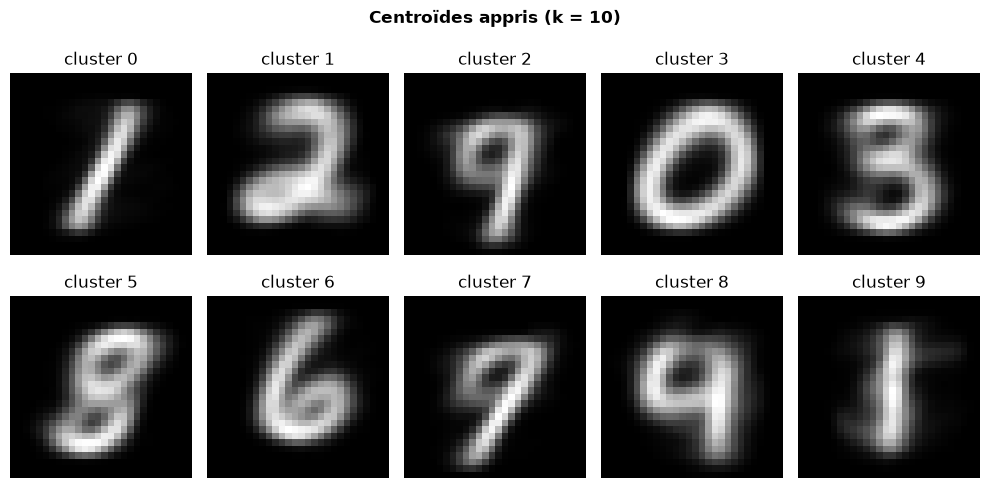

In [20]:
fig, axes = plt.subplots(2, 5, figsize=(10, 5.2))
for k, ax in enumerate(axes.ravel()):
    ax.imshow(as_image(kmeans.centroids_[k]), cmap="gray")
    ax.set_title(f"cluster {k}")
    ax.axis("off")
fig.suptitle("Centroïdes appris (k = 10)", fontweight="bold")
plt.tight_layout()
plt.show()

### 3.2 Contenu des clusters

- Certains clusters sont francs (ceux dominés par 0, 1, 2, 6) ; d'autres mélangent des chiffres à silhouette proche : le regroupement suit la forme globale du tracé et sa position.

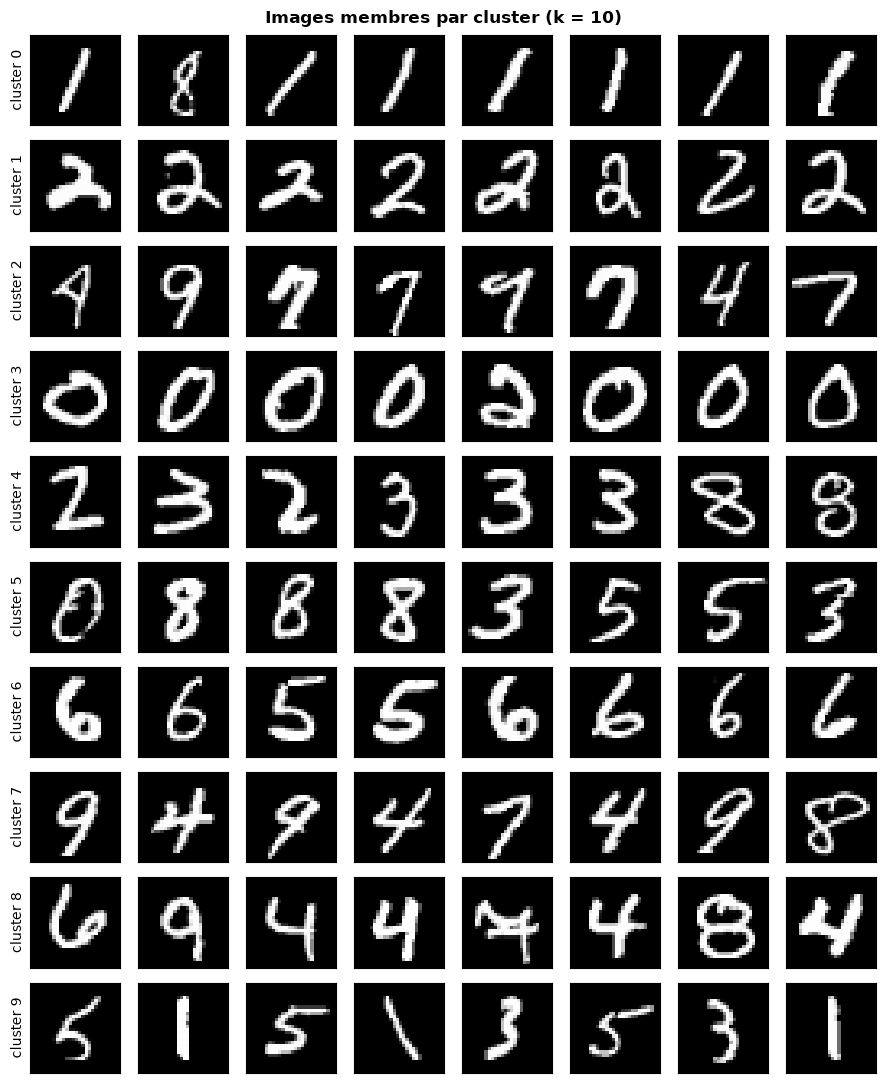

In [21]:
fig, axes = plt.subplots(10, 8, figsize=(9, 11))
for c in range(10):
    members = np.where(kmeans.labels_ == c)[0]
    picks = rng.choice(members, size=8, replace=False)
    for j in range(8):
        axes[c, j].imshow(as_image(X[picks[j]]), cmap="gray")
        axes[c, j].set_xticks([]); axes[c, j].set_yticks([])
    axes[c, 0].set_ylabel(f"cluster {c}", fontsize=10)
fig.suptitle("Images membres par cluster (k = 10)", fontweight="bold")
plt.tight_layout()
plt.show()

### 3.3 Le dictionnaire à k = 64

- En montant K, le dictionnaire devient une palette de prototypes bien plus fine.
- Chaque chiffre se décline en plusieurs variantes (inclinaison, épaisseur, boucle ouverte ou fermée) : K-Means dépense sa capacité à raffiner les styles d'écriture.

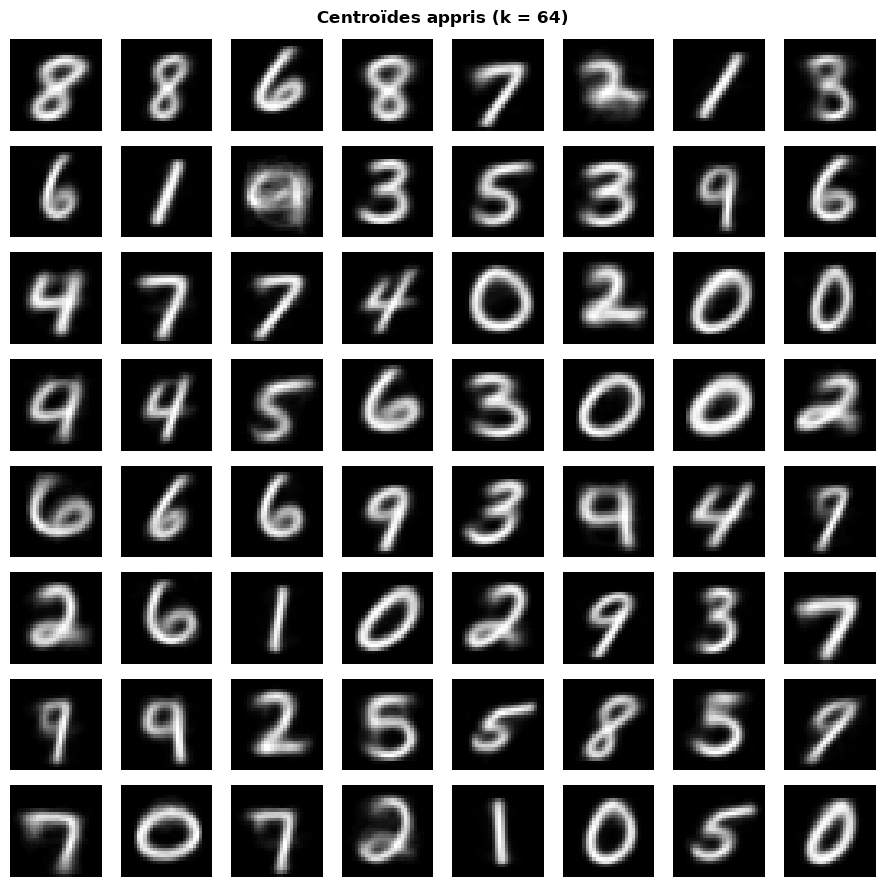

In [22]:
palette = models[64]
fig, axes = plt.subplots(8, 8, figsize=(9, 9))
for k, ax in enumerate(axes.ravel()):
    ax.imshow(as_image(palette.centroids_[k]), cmap="gray")
    ax.axis("off")
fig.suptitle("Centroïdes appris (k = 64)", fontweight="bold")
plt.tight_layout()
plt.show()

## 4. Compression et décompression

- On encode (chaque image devient un entier de cluster), puis on décode (chaque entier redevient son centroïde).
- `compression_report` mesure le poids du dictionnaire, celui des codes, et la MSE de reconstruction.
- À k = 10, gain énorme : un entier par image + dix centroïdes partagés au lieu de 784 flottants par image. En contrepartie, toutes les images d'un cluster se reconstruisent en un même chiffre moyen, d'où une MSE élevée.

In [ ]:
latent = kmeans.encode(X)
X_rec = kmeans.decode(latent)

report = compression_report(kmeans.get_codebook(), latent, X, X_rec)
for key, value in report.items():
    print(f"{key:>24} : {value}")

# latent_nature: discrete
# codebook_bytes: 31360 = 10 × 784 × 4 [octets (float32)]
# latent_bytes: 10000 = 10000 × 1 (uint8, K≤256)
# total_compressed_bytes: 41360 = 31360 + 10000
# original_bytes: 31360000 = 10000 × 784 × 4 [octets (float32)]
# compression_ratio: 758.2 = 31360000 / 41360
# reconstruction_mse: 0.0495 = MSE(original, reconstructed)

           latent_nature : discrete
          codebook_bytes : 31360
            latent_bytes : 10000
  total_compressed_bytes : 41360
          original_bytes : 31360000
       compression_ratio : 758.2205029013539
      reconstruction_mse : 0.04950663447380066


### Effet de K sur la reconstruction et la compression

- Pour chaque K déjà entraîné, on mesure inertie, MSE, ratio de compression et précision chiffre.
- Monter K enrichit le dictionnaire : la MSE baisse (meilleure reconstruction) mais le ratio baisse aussi (le dictionnaire pèse plus lourd). C'est le compromis à arbitrer.
- Seuil de stockage du code discret : `latent_bytes` passe de 1 à 2 octets par image dès que K dépasse 256 (uint8 -> uint16), visible à k = 512.

In [24]:
def majority_vote_accuracy(labels_pred, labels_true, n_clusters, n_classes=10):
    """Label each cluster by its majority digit, then score the induced classifier."""
    mapping = {}
    for c in range(n_clusters):
        members = labels_true[labels_pred == c]
        mapping[c] = np.bincount(members, minlength=n_classes).argmax() if members.size else -1
    mapped = np.array([mapping[c] for c in labels_pred])
    return (mapped == labels_true).mean(), mapping


sweep = []
for k in K_VALUES:
    model = models[k]
    lat = model.encode(X)
    rep = compression_report(model.get_codebook(), lat, X, model.decode(lat))
    acc, _ = majority_vote_accuracy(model.labels_, y, k)
    sweep.append((k, model.inertia_, rep["reconstruction_mse"], rep["compression_ratio"], acc))
    print(f"k = {k:3d}  ->  inertie = {model.inertia_:11,.0f}  |  MSE = {rep['reconstruction_mse']:.5f}"
          f"  |  ratio = {rep['compression_ratio']:8.1f}  |  précision chiffre = {acc:.2%}")

k =   3  ->  inertie =     467,196  |  MSE = 0.05959  |  ratio =   1615.8  |  précision chiffre = 30.06%
k =  10  ->  inertie =     388,132  |  MSE = 0.04951  |  ratio =    758.2  |  précision chiffre = 56.78%
k =  64  ->  inertie =     290,083  |  MSE = 0.03700  |  ratio =    148.8  |  précision chiffre = 82.60%
k = 128  ->  inertie =     262,300  |  MSE = 0.03346  |  ratio =     76.2  |  précision chiffre = 86.37%
k = 256  ->  inertie =     234,123  |  MSE = 0.02986  |  ratio =     38.6  |  précision chiffre = 88.91%
k = 512  ->  inertie =     206,342  |  MSE = 0.02632  |  ratio =     19.3  |  précision chiffre = 91.25%


### Reconstruction selon K

- Mêmes images reconstruites par chaque dictionnaire : une ligne d'originaux, une ligne par K.
- À petit K, l'image se réduit à un chiffre moyen flou, souvent le mauvais ; en montant K le tracé se resserre sur l'original et l'identité du chiffre redevient lisible.

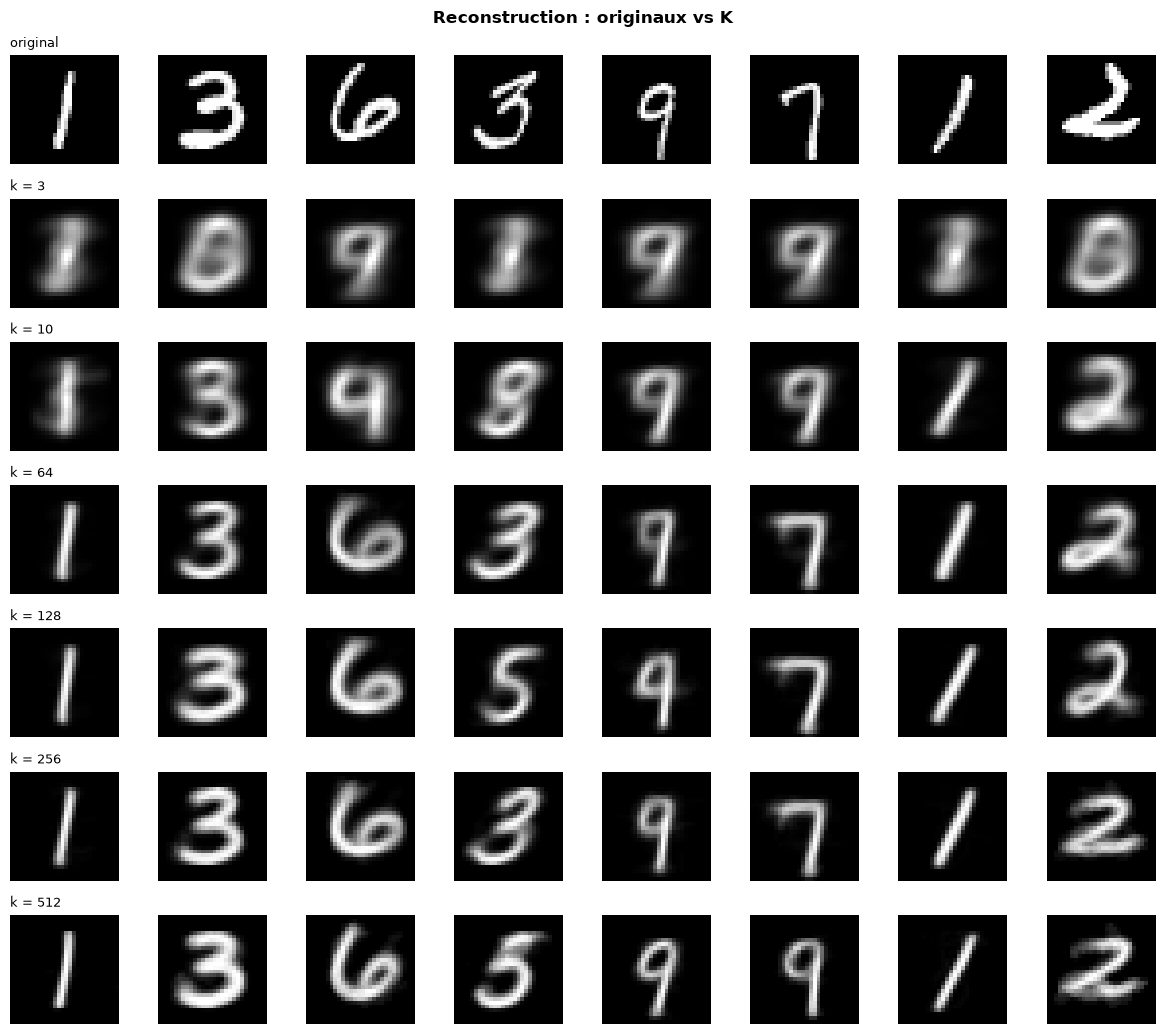

In [25]:
sample_idx = rng.choice(N, size=8, replace=False)

rows = [("original", X[sample_idx])]
for k in K_VALUES:
    model = models[k]
    rows.append((f"k = {k}", model.decode(model.encode(X[sample_idx]))))

fig, axes = plt.subplots(len(rows), 8, figsize=(12, 1.5 * len(rows)))
for r, (label, imgs) in enumerate(rows):
    for c in range(8):
        axes[r, c].imshow(as_image(imgs[c]), cmap="gray")
        axes[r, c].axis("off")
    axes[r, 0].set_title(label, fontsize=9, loc="left")
fig.suptitle("Reconstruction : originaux vs K", fontweight="bold")
plt.tight_layout()
plt.show()

## 5. Les clusters correspondent-ils aux chiffres ?

- K-Means ignore les étiquettes ; on regarde a posteriori le lien avec les chiffres.
- Chaque cluster reçoit son chiffre majoritaire ; la pureté d'un cluster = part de ce chiffre dominant.
- La précision par vote majoritaire est la moyenne de ces parts, pondérée par la taille des clusters (colonne "précision chiffre" de la table du balayage ci-dessus).

### Vote majoritaire et pureté à k = 10

- Précision par vote majoritaire, puis pour chaque cluster son chiffre dominant, sa pureté et sa taille.
- La table de contingence qui suit croise clusters et chiffres réels.

In [26]:
acc, mapping = majority_vote_accuracy(kmeans.labels_, y, 10)
print(f"Précision par vote majoritaire (chiffre, k = 10) : {acc:.2%}")
print(f"Niveau du hasard (10 chiffres équilibrés)        : {1 / 10:.2%}\n")
for c in range(10):
    counts = np.bincount(y[kmeans.labels_ == c], minlength=10)
    purity = counts.max() / counts.sum()
    print(f"cluster {c}: chiffre dominant = {class_names[mapping[c]]:>2}  |  pureté = {purity:5.1%}  |  taille = {counts.sum()}")

Précision par vote majoritaire (chiffre, k = 10) : 56.78%
Niveau du hasard (10 chiffres équilibrés)        : 10.00%

cluster 0: chiffre dominant =  1  |  pureté = 78.4%  |  taille = 731
cluster 1: chiffre dominant =  2  |  pureté = 90.9%  |  taille = 729
cluster 2: chiffre dominant =  7  |  pureté = 36.7%  |  taille = 1184
cluster 3: chiffre dominant =  0  |  pureté = 94.5%  |  taille = 833
cluster 4: chiffre dominant =  3  |  pureté = 51.2%  |  taille = 1167
cluster 5: chiffre dominant =  8  |  pureté = 44.9%  |  taille = 1126
cluster 6: chiffre dominant =  6  |  pureté = 85.7%  |  taille = 881
cluster 7: chiffre dominant =  7  |  pureté = 41.2%  |  taille = 1066
cluster 8: chiffre dominant =  4  |  pureté = 40.3%  |  taille = 935
cluster 9: chiffre dominant =  1  |  pureté = 40.5%  |  taille = 1348


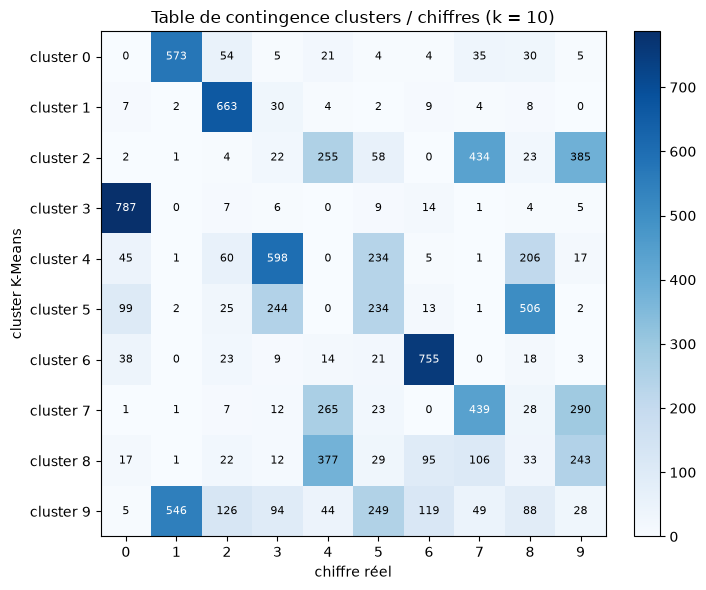

In [27]:
contingency = np.zeros((10, 10), dtype=int)
for c in range(10):
    contingency[c] = np.bincount(y[kmeans.labels_ == c], minlength=10)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(contingency, cmap="Blues")
ax.set_xticks(range(10)); ax.set_xticklabels(class_names)
ax.set_yticks(range(10)); ax.set_yticklabels([f"cluster {c}" for c in range(10)])
ax.set_xlabel("chiffre réel"); ax.set_ylabel("cluster K-Means")
for c in range(10):
    for s in range(10):
        ax.text(s, c, contingency[c, s], ha="center", va="center",
                color="white" if contingency[c, s] > contingency.max() / 2 else "black", fontsize=8)
ax.set_title("Table de contingence clusters / chiffres (k = 10)")
fig.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.show()

- Précision très au-dessus du hasard (~57% contre 10%).
- Correspondance imparfaite malgré tout : deux clusters se partagent le 1 et deux le 7, tandis que 5 et 9 n'ont aucun cluster dominant, absorbés par leurs voisins de tracé (3/8 et 4/7).
- Pureté très étalée (~37% à ~95%) : les chiffres à silhouette isolée (0, 1, 2, 6) forment des clusters francs, ceux à tracé ambigu se mélangent.

## 6. Génération de données

- Vu comme modèle génératif, K-Means définit une loi a priori sur les codes : une catégorielle sur les K indices de cluster, estimée par les fréquences d'assignation.
- Générer = tirer un indice selon cette loi, puis renvoyer son centroïde (décodage déterministe).
- Support de la loi = exactement les K centroïdes : aucune image hors dictionnaire.
- On compare plusieurs K pour voir le vocabulaire s'enrichir.

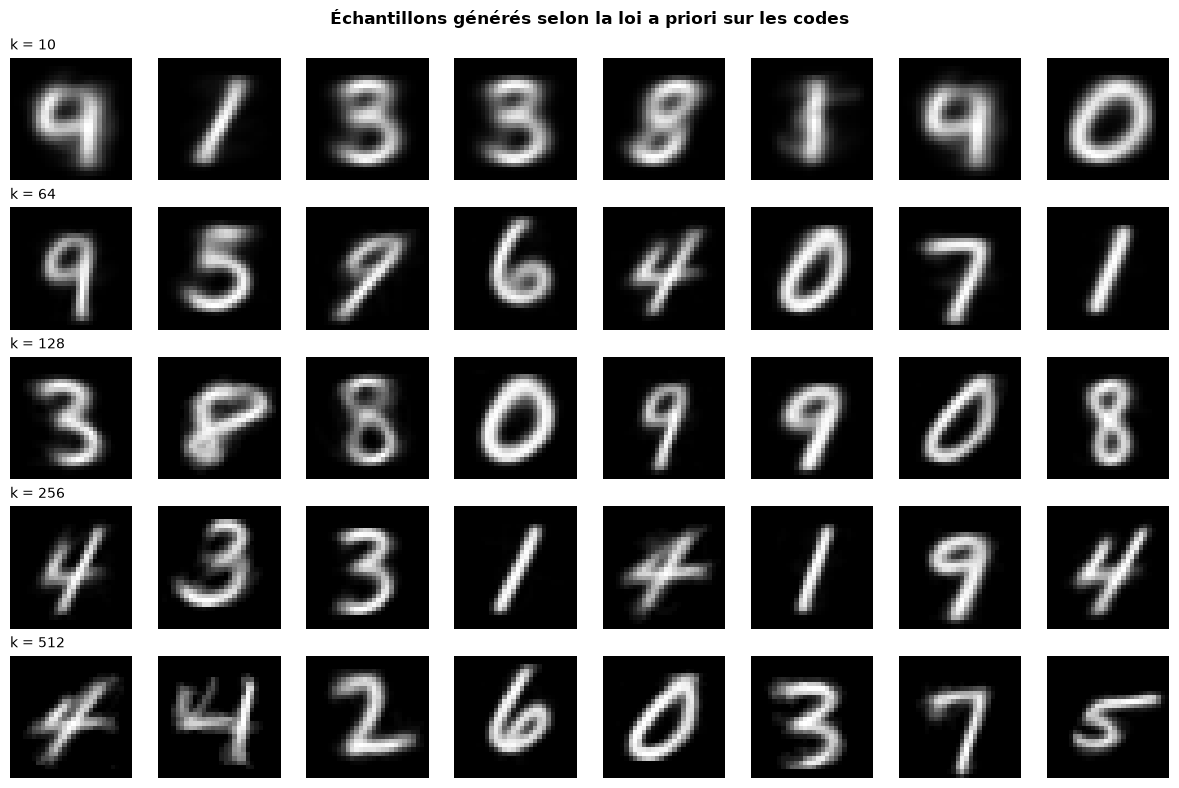

In [28]:
def sample_from(model, n_samples):
    """Draw cluster codes from the empirical assignment frequencies, decode to centroids."""
    prior = np.bincount(model.labels_, minlength=model.n_clusters) / len(model.labels_)
    codes = Latent(array=rng.choice(model.n_clusters, size=n_samples, p=prior), nature="discrete")
    return codes.array, model.decode(codes)


fig, axes = plt.subplots(5, 8, figsize=(12, 8))
for row, model in enumerate([models[10], models[64], models[128], models[256], models[512]]):
    codes, gen = sample_from(model, 8)
    for col in range(8):
        axes[row, col].imshow(as_image(gen[col]), cmap="gray")
        axes[row, col].axis("off")
    axes[row, 0].set_title(f"k = {model.n_clusters}", fontsize=10, loc="left")
fig.suptitle("Échantillons générés selon la loi a priori sur les codes", fontweight="bold")
plt.tight_layout()
plt.show()